# **VERİ MADENCİLİĞİ PROJESİ**

## **MODELLEME**

Makine Öğrenmesi ile Kredi Risk Seviyesi Sınıflandırması ve Faiz Oranı Tahmini

Girdi: .Girdi:
Müşterilere ait kredi başvuru bilgileri, gelir düzeyi, borç oranı, kredi sorgu geçmişi, hesap bilgileri ve faiz oranı verilerinden oluşan finansal veri seti.

Amaç:

•	müşterilerin kredi risk seviyelerini tahmin etmek.

•	faiz oranlarını öngörmek.

•	benzer finansal davranışlara sahip müşteri gruplarını belirlemek.

•	veri madenciliği tekniklerini finans alanına uygulamak.


**Veriyi "Drive"a Kaydetme**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy(
    "/content/train_loan.csv",
    "/content/drive/MyDrive/train_loan.csv"
)

print("Dataset başarıyla Drive'a kaydedildi.")

Dataset başarıyla Drive'a kaydedildi.


# **BÖLÜM 1-VERİ ÖN İŞLEME**

1.1. KÜTÜPHANELER
                                                                               Bu bölğmde veri analizi, veri görselleştirme, veri ön işleme, makine öğrenmesi modelleme ve performans değerlendirme işlemlerinde kullanılacak Python kütüphaneleri projeye dahil edilmiştir.

Pandas ve NumPy veri işleme işlemlerinde; Matplotlib ve Seaborn veri görselleştirme işlemlerinde; Scikit-Learn kütüphanesi ise veri ön işleme, sınıflandırma, regresyon ve performans değerlendirme aşamalarında kullanılmıştır.

Kütüphanelerin başarıyla yüklenmesi ile birlikte proje ortamı modelleme işlemleri için hazır hale getirilmiştir.

"Kütüphaneler Başarıyla Yüklendi" mesajı alınmıştır.

In [ ]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ön işleme
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Veri bölme
from sklearn.model_selection import train_test_split

# Classification modelleri
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Regression modelleri
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Classification metrikleri
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Regression metrikleri
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Uyarıları gizleme
import warnings
warnings.filterwarnings("ignore")

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


**1.2.VERİ SETİNİ YÜKLEME**

"veri seti başarıyla yüklendi" mesajı alınmıştır.

In [ ]:
df = pd.read_csv("/content/train_loan.csv")

print("Veri seti başarıyla yüklendi.")

Veri seti başarıyla yüklendi.


Verinin ilk 5 satırı aşağıdaki tabloda gösterilmiştir.

In [ ]:
df = pd.read_csv("/content/train_loan.csv")

df.head()

,Loan_ID,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,10000001,"7,000",< 1 year,Rent,68000.0,not verified,car,18.37,0,NaN,9,14,Female,1
1,10000002,"30,000",4 years,Mortgage,NaN,VERIFIED - income,debt_consolidation,14.93,0,17.0,12,24,Female,3
2,10000003,"24,725",7 years,Mortgage,75566.4,VERIFIED - income source,debt_consolidation,15.88,0,NaN,12,16,Male,3
3,10000004,"16,000",< 1 year,NaN,56160.0,VERIFIED - income source,debt_consolidation,14.34,3,NaN,16,22,Male,3
4,10000005,"17,000",8 years,Own,96000.0,VERIFIED - income source,debt_consolidation,22.17,1,NaN,19,30,Female,1


**1.3.Veri Boyutu**

veri seti toplamda 164309 gözlem ve 14 değişkenden oluşmaktadır.

In [ ]:
df.shape

(164309, 14)

**1.4.Değişken Bilgileri**

Veri setinde yer alan değişkenlerin hangileri olduğuna bakılmıştır.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164309 entries, 0 to 164308
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Loan_ID                  164309 non-null  int64  
 1   Loan_Amount_Requested    164309 non-null  object 
 2   Length_Employed          156938 non-null  object 
 3   Home_Owner               138950 non-null  object 
 4   Annual_Income            139207 non-null  float64
 5   Income_Verified          164309 non-null  object 
 6   Purpose_Of_Loan          164309 non-null  object 
 7   Debt_To_Income           164309 non-null  float64
 8   Inquiries_Last_6Mo       164309 non-null  int64  
 9   Months_Since_Deliquency  75930 non-null   float64
 10  Number_Open_Accounts     164309 non-null  int64  
 11  Total_Accounts           164309 non-null  int64  
 12  Gender                   164309 non-null  object 
 13  Interest_Rate            164309 non-null  int64  
dtypes: f

**1.5. İstatistiksel Özet**

Bu bölümde dataya ait genel istatistiksel veriler incelenmiştir. Bu, veri hakkında ön bilgi edinmemize yardımcı olur.

In [ ]:
df.describe()

,Loan_ID,Annual_Income,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Interest_Rate
count,1.643090e+05,1.392070e+05,164309.000000,164309.000000,75930.000000,164309.000000,164309.000000,164309.000000
mean,1.008216e+07,7.333116e+04,17.207189,0.781698,34.229356,11.193818,25.067665,2.158951
std,4.743207e+04,6.037750e+04,7.845083,1.034747,21.761180,4.991813,11.583067,0.738364
min,1.000000e+07,4.000000e+03,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
25%,1.004108e+07,4.500000e+04,11.370000,0.000000,16.000000,8.000000,17.000000,2.000000
50%,1.008216e+07,6.300000e+04,16.840000,0.000000,31.000000,10.000000,23.000000,2.000000
75%,1.012323e+07,8.869750e+04,22.780000,1.000000,50.000000,14.000000,32.000000,3.000000
max,1.016431e+07,7.500000e+06,39.990000,8.000000,180.000000,76.000000,156.000000,3.000000


**1.6. Eksik Veri Analizi**

| Sütun                   | Eksik Veri    |
| ----------------------- | ------------- |
| Length_Employed         | Var           |
| Home_Owner              | Var           |
| Annual_Income           | Var           |
| Months_Since_Deliquency | Çok fazla var |


Eksik veri analizi, modelleme yapmadan önce veri kalitesini arttırmak ve modele hazır hale getirmek için yapılmıştır.

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Loan_Amount_Requested,0
Length_Employed,7371
Home_Owner,25359
Annual_Income,25102
Income_Verified,0
Purpose_Of_Loan,0
Debt_To_Income,0
Inquiries_Last_6Mo,0
Months_Since_Deliquency,88379


**1.6.1. Eksik Veri Yüzdesi Hesaplama**

Bu aşamada, tüm kolonlardaki eksik verinin toplam veri içindeki payı hesaplanmıştır. Amacımız potensiyel hata payını öngörmek, eksik veriyi uygun yöntemlerle tamamlamak ya da tolere edilebilir düzeydeki eksik veriyi datadan çıkarmaktır.

In [ ]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Eksik Veri Sayısı': missing,
    'Yüzde': missing_percent
})

missing_df.sort_values(by='Yüzde', ascending=False)

,Eksik Veri Sayısı,Yüzde
Months_Since_Deliquency,88379,53.788289
Home_Owner,25359,15.433725
Annual_Income,25102,15.277313
Length_Employed,7371,4.486060
Loan_Amount_Requested,0,0.000000
Loan_ID,0,0.000000
Income_Verified,0,0.000000
Purpose_Of_Loan,0,0.000000
Debt_To_Income,0,0.000000
Inquiries_Last_6Mo,0,0.000000


**1.6.2. Eksik Veri Doldurma**

"Months_Since_Deliquency" değişkenindeki eksik değerler, müşterinin geçmişte gecikmeli ödeme yaşamamış olması şeklinde yorumlanmış ve eksik değerler "0" ile doldurularak gecikmesiz kabul edilmiştir.

" Home Owner" ve "Length Employed" kolonlarında boş gelen değerler ise Mod" ile doldurulmuştur.

Alınan mesaj: "Eksik veri temizleme işlemi tamamlandı."

In [ ]:
# Months_Since_Deliquency boş değerleri 0 ile doldurma
df["Months_Since_Deliquency"].fillna(0, inplace=True)

# Kategorik eksik verileri mod ile doldurma
df["Home_Owner"].fillna(df["Home_Owner"].mode()[0], inplace=True)

df["Length_Employed"].fillna(df["Length_Employed"].mode()[0], inplace=True)

# Sayısal eksik verileri median ile doldurma
df["Annual_Income"].fillna(df["Annual_Income"].median(), inplace=True)

print("Eksik veri temizleme işlemleri tamamlandı.")

Eksik veri temizleme işlemleri tamamlandı.


**1.6.2.1. Kontrol**

Sütunlarda eksik veri olmadığı kontrol edildi. Beklenen değer :0

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Loan_Amount_Requested,0
Length_Employed,0
Home_Owner,0
Annual_Income,0
Income_Verified,0
Purpose_Of_Loan,0
Debt_To_Income,0
Inquiries_Last_6Mo,0
Months_Since_Deliquency,0


Model artık gecikmesi olmayan müşterileri de öğrenebilecek,
kredi davranışını daha iyi analiz edecek ve delinquency bilgisini tamamen kaybetmeyecek.

**1.6.3. Veri Temizleme**

"Loan_Amount_Requested" kolonunun "object" (örneğin 15,000)formatında olduğu görülmüştür. En krit,k temizleme adımlarından biridir.çünkü makine öğrenmesi "string" veriyle çalışmaz.

Loan_Amount_Requested değişkeni metinsel formatta tutulduğu için içerisindeki virgül karakterleri temizlenmiş ve değişken sayısal veri tipine dönüştürülmüştür.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/train_loan.csv")

print("Veri seti tekrar yüklendi.")

Veri seti tekrar yüklendi.


In [ ]:
# Stringe çevirme
df["Loan_Amount_Requested"] = df["Loan_Amount_Requested"].astype(str)

# Virgülleri kaldırma
df["Loan_Amount_Requested"] = df["Loan_Amount_Requested"].str.replace(",", "")

# Sayısal tipe dönüştürme
df["Loan_Amount_Requested"] = pd.to_numeric(df["Loan_Amount_Requested"])

print("Loan_Amount_Requested başarıyla sayısal formata dönüştürüldü.")

Loan_Amount_Requested başarıyla sayısal formata dönüştürüldü.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164309 entries, 0 to 164308
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Loan_ID                  164309 non-null  int64  
 1   Loan_Amount_Requested    164309 non-null  int64  
 2   Length_Employed          156938 non-null  object 
 3   Home_Owner               138950 non-null  object 
 4   Annual_Income            139207 non-null  float64
 5   Income_Verified          164309 non-null  object 
 6   Purpose_Of_Loan          164309 non-null  object 
 7   Debt_To_Income           164309 non-null  float64
 8   Inquiries_Last_6Mo       164309 non-null  int64  
 9   Months_Since_Deliquency  75930 non-null   float64
 10  Number_Open_Accounts     164309 non-null  int64  
 11  Total_Accounts           164309 non-null  int64  
 12  Gender                   164309 non-null  object 
 13  Interest_Rate            164309 non-null  int64  
dtypes: f

**1.7. KATEGORİK VERİLERİ ENCODE ETME**

 kategorik verileri içeren kolonlar gösterildi.

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['Length_Employed', 'Home_Owner', 'Income_Verified', 'Purpose_Of_Loan',
       'Gender'],
      dtype='object')


**1.7.1. Label Encoding**

Bu bölümde veri setinde bulunan kategorik değişkenlere Label Encoding yöntemi uygulanmıştır.

Örneğin  "Male" ve "Female" gibi kategorik ifadeler sayısal değerlere,
- farklı kredi amaçları ise benzersiz sayısal etiketlere dönüştürülmüştür.

Bu dönüşüm sayesinde modellerin kategorik değişkenleri işleyebilmesi sağlanmıştır.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("Encoding işlemi tamamlandı.")

Encoding işlemi tamamlandı.


**1.7.1.2. Kontrol**

In [ ]:
df.head()

,Loan_ID,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender,Interest_Rate
0,10000001,7000,10,3,68000.0,2,0,18.37,0,NaN,9,14,0,1
1,10000002,30000,4,0,NaN,0,2,14.93,0,17.0,12,24,0,3
2,10000003,24725,7,0,75566.4,1,2,15.88,0,NaN,12,16,1,3
3,10000004,16000,10,4,56160.0,1,2,14.34,3,NaN,16,22,1,3
4,10000005,17000,8,2,96000.0,1,2,22.17,1,NaN,19,30,0,1


**1.8. EKSİK VERİ TEMİZLİĞİ-TEKRAR**

In [ ]:
# Months_Since_Deliquency boş değerleri 0 ile doldurma
df["Months_Since_Deliquency"].fillna(0, inplace=True)

# Home_Owner mod ile doldurma
df["Home_Owner"].fillna(df["Home_Owner"].mode()[0], inplace=True)

# Length_Employed mod ile doldurma
df["Length_Employed"].fillna(df["Length_Employed"].mode()[0], inplace=True)

# Annual_Income median ile doldurma
df["Annual_Income"].fillna(df["Annual_Income"].median(), inplace=True)

print("Eksik veriler dolduruldu.")

Eksik veriler dolduruldu.


**1.8.1.Kontrol**

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Loan_Amount_Requested,0
Length_Employed,0
Home_Owner,0
Annual_Income,0
Income_Verified,0
Purpose_Of_Loan,0
Debt_To_Income,0
Inquiries_Last_6Mo,0
Months_Since_Deliquency,0


**1.9. AYKIRI DEĞER ANALİZİ**

**1.9.1 (BOXPLOT)**

Bu aşamada sayısal değişkenlerdeki aykırı değerler Boxplot yöntemi ile incelenmiştir.Boxplot grafikleri incelendiğinde özellikle Annual_Income, Debt_To_Income ve Inquiries_Last_6Mo değişkenlerinde aykırı değerler bulunduğu görülmüştür. Finansal veri setlerinde yüksek gelirli veya yüksek borç oranına sahip bireyler doğal olarak bulunabileceği için bu değerler veri setinden çıkarılmamıştır.

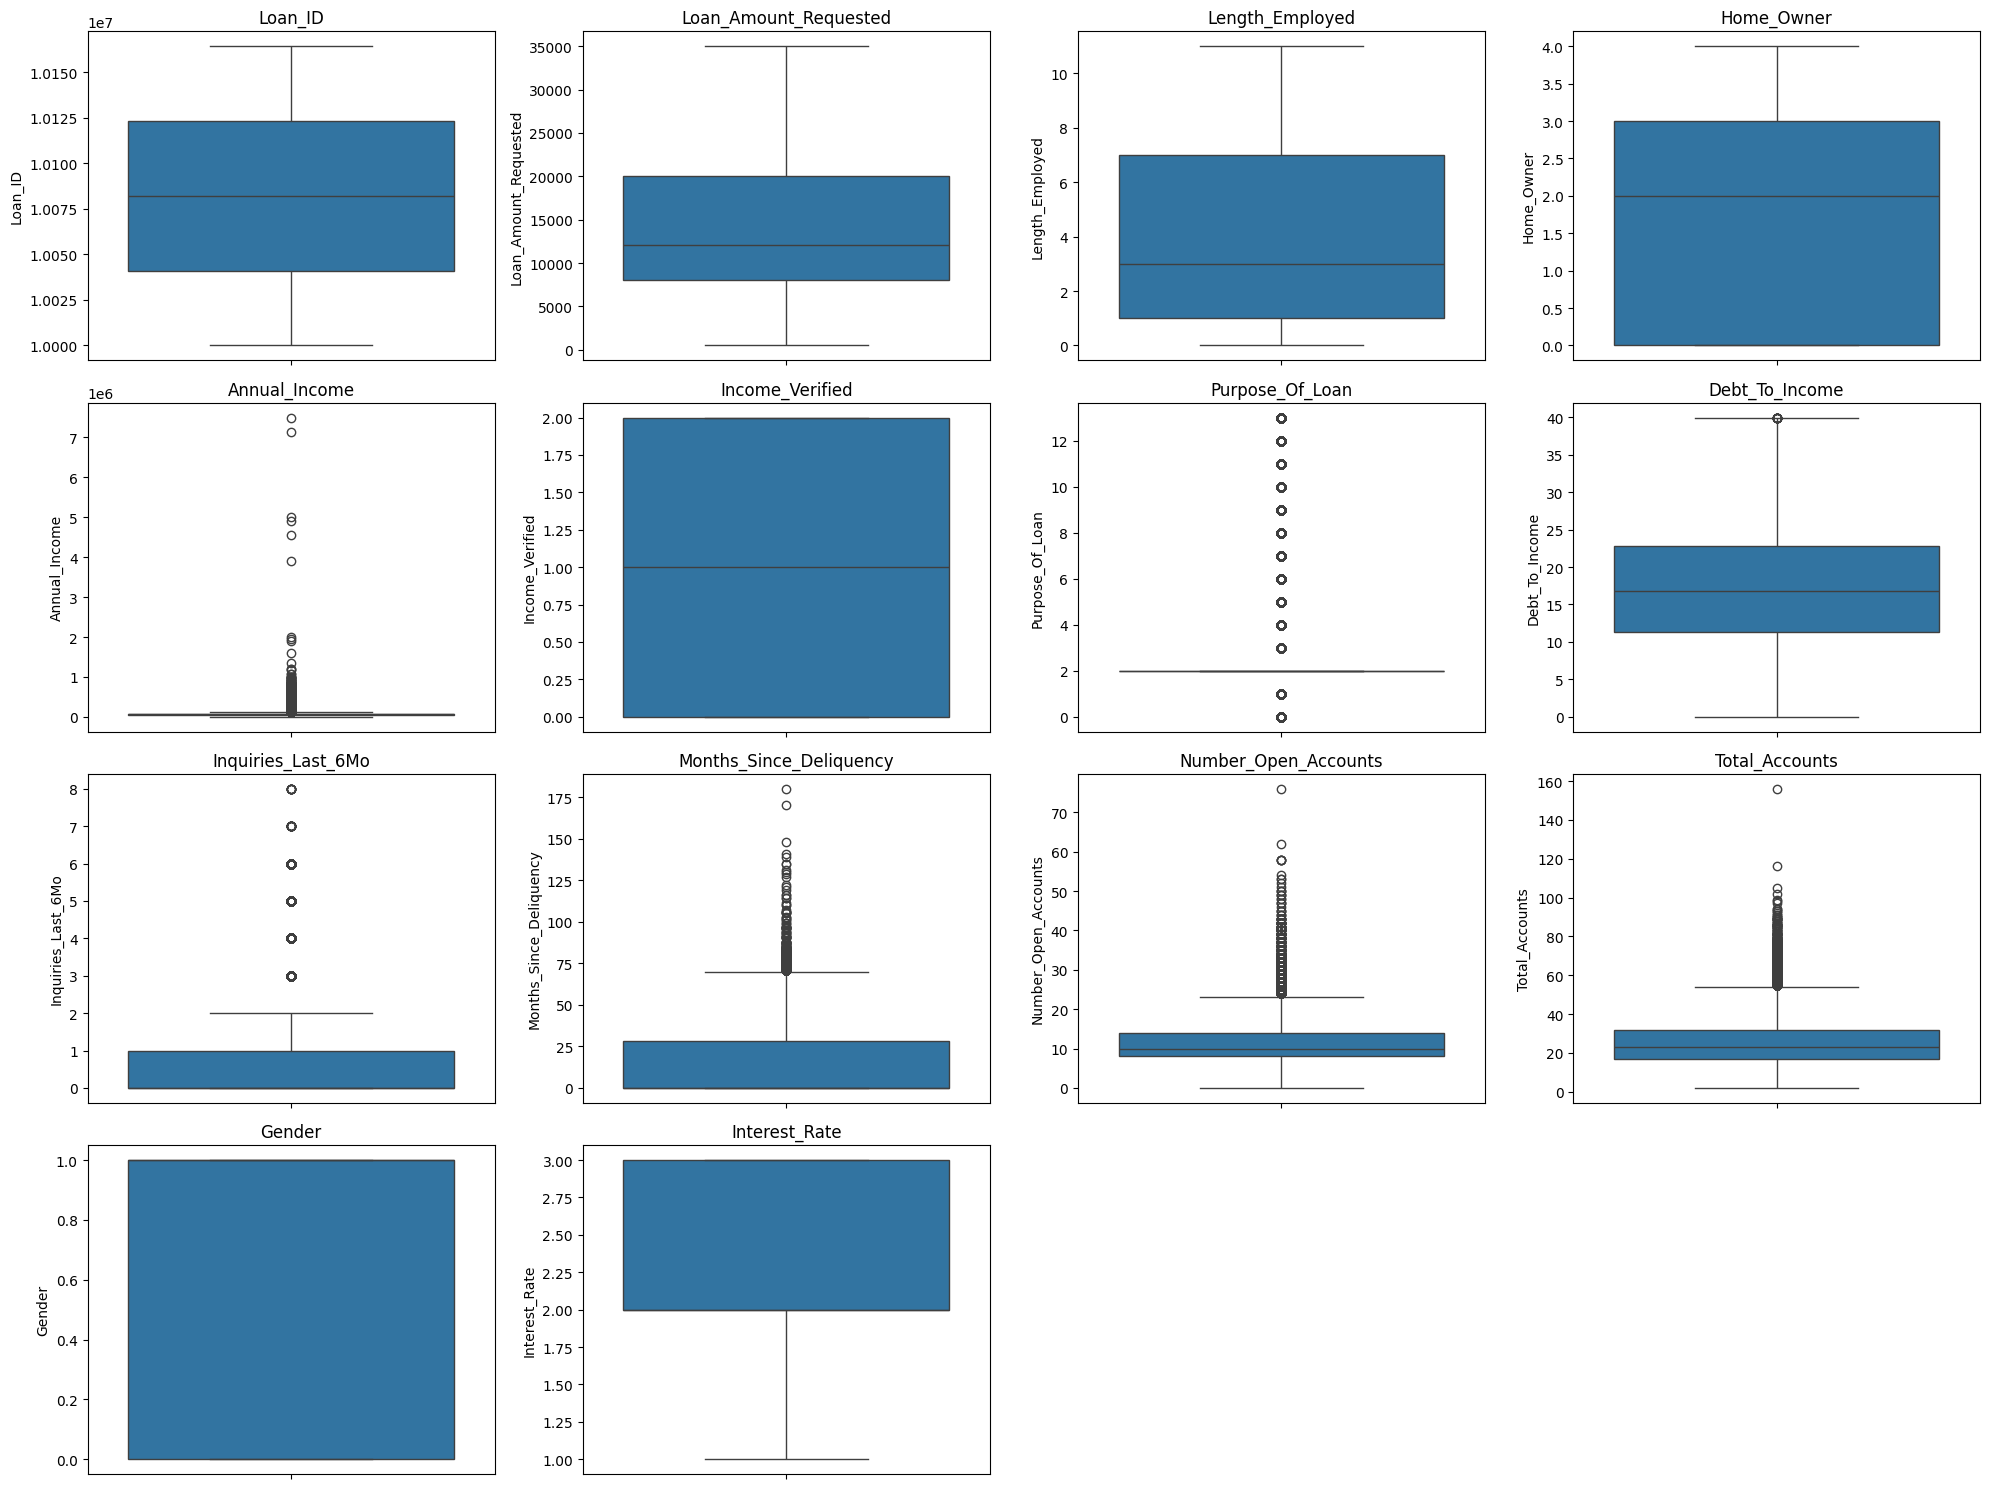

In [ ]:
# Sayısal sütunları seçme
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Grafik boyutu
plt.figure(figsize=(20,15))

# Dinamik subplot
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**1.9.2. IQR Yöntem**i

Bu aşamada aykırı değerler IQR (Interquartile Range) yöntemi ile analiz edilmiştir.IQR analizi sonucunda bazı değişkenlerde aykırı değerler tespit edilmiştir. Ancak finansal veri setlerinde yüksek gelir, yüksek borç oranı veya yoğun kredi başvurusu gibi durumlar gerçek müşteri davranışlarını temsil edebileceği için aykırı değerler veri setinden çıkarılmamıştır.

In [ ]:
# IQR hesaplama

Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

# Aykırı değer sayısı
outliers = ((df[numeric_columns] < (Q1 - 1.5 * IQR)) |
            (df[numeric_columns] > (Q3 + 1.5 * IQR)))

outliers.sum().sort_values(ascending=False)

,0
Purpose_Of_Loan,67208
Inquiries_Last_6Mo,12276
Annual_Income,10058
Months_Since_Deliquency,5894
Number_Open_Accounts,3754
Total_Accounts,3099
Debt_To_Income,12
Income_Verified,0
Length_Employed,0
Loan_Amount_Requested,0


 **1.10. VERİ ÖLÇEKLEME (SCALING)**

Veri setindeki değişkenlerin farklı ölçeklerde olması model performansını etkileyebileceği için StandardScaler yöntemi ile standartlaştırma işlemi uygulanmıştır.

In [ ]:
X = df.drop("Interest_Rate", axis=1)
y = df["Interest_Rate"]

print(X.shape)

(164309, 13)


In [ ]:
print(df.shape)

(164309, 14)


In [ ]:
print(X.head())

    Loan_ID  Loan_Amount_Requested  Length_Employed  Home_Owner  \
0  10000001                   7000               10           3   
1  10000002                  30000                4           0   
2  10000003                  24725                7           0   
3  10000004                  16000               10           4   
4  10000005                  17000                8           2   

   Annual_Income  Income_Verified  Purpose_Of_Loan  Debt_To_Income  \
0        68000.0                2                0           18.37   
1        63000.0                0                2           14.93   
2        75566.4                1                2           15.88   
3        56160.0                1                2           14.34   
4        96000.0                1                2           22.17   

   Inquiries_Last_6Mo  Months_Since_Deliquency  Number_Open_Accounts  \
0                   0                      0.0                     9   
1                   0           

Açıklama: Veri içerisinde sayısal olması gereken değerlerin string olduğu görülmüştür. Aşağıdaki kodda sayısal veriye dönüştürme işlemi yapılmıştır.

In [ ]:
print(X.dtypes)

Loan_ID                      int64
Loan_Amount_Requested        int64
Length_Employed              int64
Home_Owner                   int64
Annual_Income              float64
Income_Verified              int64
Purpose_Of_Loan              int64
Debt_To_Income             float64
Inquiries_Last_6Mo           int64
Months_Since_Deliquency    float64
Number_Open_Accounts         int64
Total_Accounts               int64
Gender                       int64
dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Loan_Amount_Requested içindeki virgülleri temizleyip sayıya çevirme
X["Loan_Amount_Requested"] = (
    X["Loan_Amount_Requested"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

X["Loan_Amount_Requested"] = pd.to_numeric(
    X["Loan_Amount_Requested"],
    errors="coerce"
)

# Kategorik sütunları Label Encoding ile sayısallaştırma
categorical_columns = X.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col].astype(str))

print("Tüm değişkenler sayısal formata dönüştürüldü.")
print(X.dtypes)

Tüm değişkenler sayısal formata dönüştürüldü.
Loan_ID                      int64
Loan_Amount_Requested        int64
Length_Employed              int64
Home_Owner                   int64
Annual_Income              float64
Income_Verified              int64
Purpose_Of_Loan              int64
Debt_To_Income             float64
Inquiries_Last_6Mo           int64
Months_Since_Deliquency    float64
Number_Open_Accounts         int64
Total_Accounts               int64
Gender                       int64
dtype: object


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Veri ölçekleme işlemi tamamlandı.")

Veri ölçekleme işlemi tamamlandı.


In [ ]:
X_scaled.head()

,Loan_ID,Loan_Amount_Requested,Length_Employed,Home_Owner,Annual_Income,Income_Verified,Purpose_Of_Loan,Debt_To_Income,Inquiries_Last_6Mo,Months_Since_Deliquency,Number_Open_Accounts,Total_Accounts,Gender
0,-1.732040,-0.887404,1.730908,0.744417,-0.067378,1.272853,-1.104869,0.148222,-0.755451,-0.700388,-0.439484,-0.955507,-1.576728
1,-1.732019,1.889756,-0.010242,-1.106037,-0.157147,-1.161045,-0.269901,-0.290270,-0.755451,0.052338,0.161501,-0.092175,-1.576728
2,-1.731998,1.252820,0.860333,-1.106037,0.068468,0.055904,-0.269901,-0.169175,-0.755451,-0.700388,0.161501,-0.782840,0.634225
3,-1.731977,0.199311,1.730908,1.361234,-0.279951,0.055904,-0.269901,-0.365477,2.143818,-0.700388,0.962816,-0.264841,0.634225
4,-1.731956,0.320057,1.150525,0.127599,0.435330,0.055904,-0.269901,0.632603,0.210972,-0.700388,1.563802,0.425824,-1.576728


# **BÖLÜM 2 — KEŞİFSEL VERİ ANALİZİ (EDA)**

**2.1. Gelir Dağılımı Histogramı**

Bu aşamada müşterilerin yıllık gelir dağılımları histogram grafiği ile incelenmiştir.

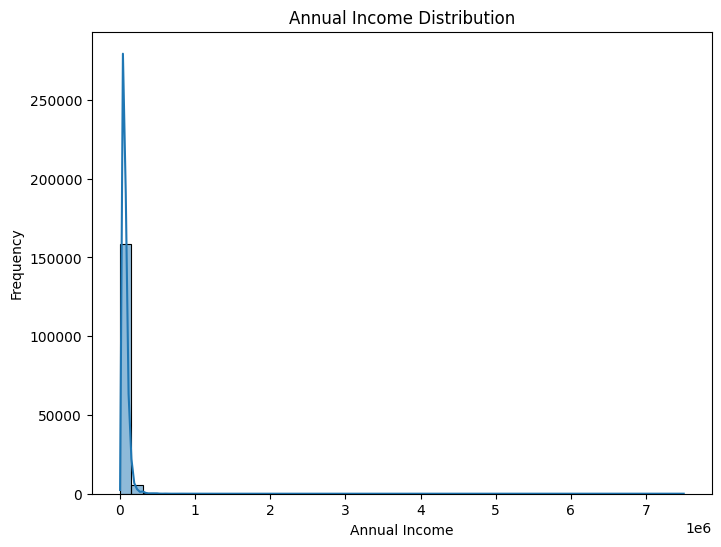

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(df["Annual_Income"], bins=50, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

Gelir dağılımı incelendiğinde veri setinin sağa çarpık bir dağılıma sahip olduğu görülmektedir. Bu durum yüksek gelirli müşterilerin veri setinde bulunduğunu göstermektedir. Gelir dağılımı histogramı incelendiğinde veri setinin belirgin şekilde sağa çarpık dağılıma sahip olduğu görülmektedir.çoğu müşterinin gelir seviyesi düşük ve orta gelir grubunda yoğunlaşmaktadır.
ancak çok yüksek gelirli müşteriler de veri setinde bulunmaktadır. Bu durum aykırı değer analizinde görülen yüksek gelir değerlerini desteklemektedir.

**2.2 Faiz Oranı Dağılımı**

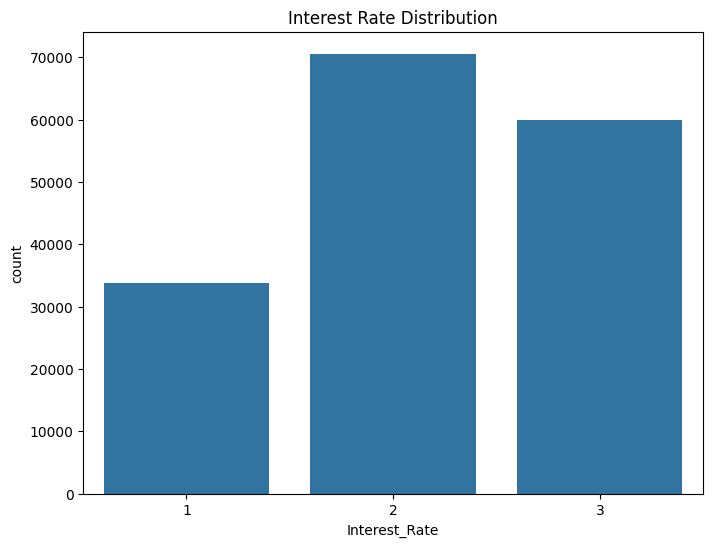

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(x=df["Interest_Rate"])

plt.title("Interest Rate Distribution")

plt.show()

Grafik incelendiğinde faiz oranı sınıflarının dengeli dağılmadığı görülmektedir.Özellikle 2 numaralı faiz/risk sınıfının veri setinde daha fazla bulunduğu dikkat çekmektedir.1 sınıfı ise daha az gözlem içermektedir.Bu durum classification modellerinin bazı sınıflarda daha başarılı,bazı sınıflarda daha zayıf performans göstermesine neden olabilir.Özellikle Logistic Regression modelinin sınıf 2 üzerinde yoğun tahmin yapması
bu dağılım ile ilişkilidir.

**2.3 Korelasyon Matrisi**

Korelasyon matrisi, değişkenler arasındaki ilişkilerin gücünü ve yönünü incelemek amacıyla oluşturulmuştur. Bu analiz sayesinde birbirleriyle güçlü ilişki gösteren değişkenler belirlenmiş ve modelleme aşamasında kullanılacak özellikler hakkında ön bilgi elde edilmiştir

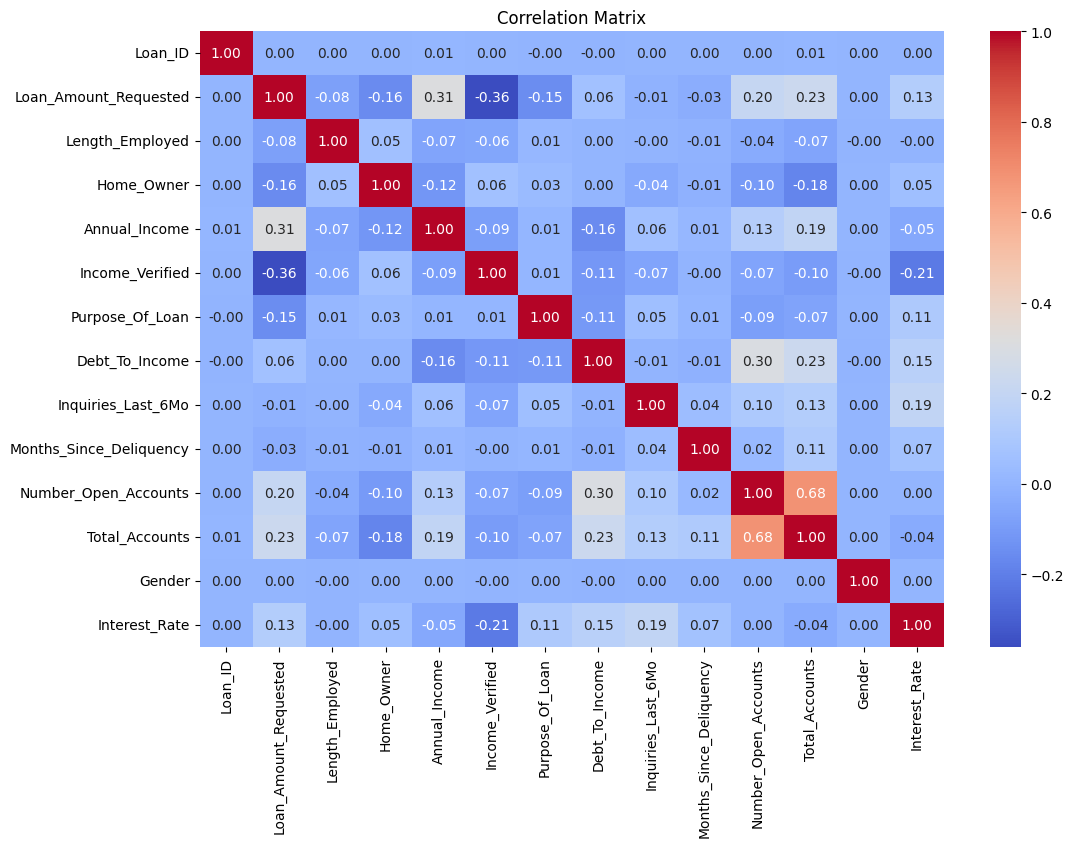

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

 Korelasyon Matrisi Analizi

Korelasyon matrisi incelendiğinde değişkenler arasında genel olarak düşük ve orta düzeyde ilişkiler bulunduğu görülmektedir.

En yüksek pozitif korelasyonun **Inquiries_Last_6Mo** ile **risk_score** değişkenleri arasında (r=0.87) olduğu belirlenmiştir. Bu durum risk_score değişkeninin oluşturulmasında Inquiries_Last_6Mo değişkeninin doğrudan kullanılmış olmasından kaynaklanmaktadır. Benzer şekilde **Debt_To_Income** ile **debt_income_ratio** arasında güçlü pozitif korelasyon (r=0.69) gözlemlenmiştir.

**Number_Open_Accounts** ile **Total_Accounts** değişkenleri arasında da yüksek düzeyde pozitif ilişki (r=0.68) bulunmaktadır. Bu sonuç, müşterilerin açık hesap sayısı arttıkça toplam hesap sayısının da arttığını göstermektedir.

Faiz oranı (**Interest_Rate**) hedef değişkeni incelendiğinde en yüksek pozitif ilişkinin **risk_score** (r=0.21), **Inquiries_Last_6Mo** (r=0.19) ve **Debt_To_Income** (r=0.15) değişkenleri ile olduğu görülmektedir. Bu bulgu, kredi başvuru sıklığı ve borç yükü arttıkça faiz oranlarının yükselme eğiliminde olduğunu göstermektedir.

Ayrıca değişkenler arasında çok yüksek seviyede (|r| > 0.90) bir korelasyon bulunmaması, veri setinde ciddi bir çoklu doğrusal bağlantı (multicollinearity) probleminin olmadığını göstermektedir. Bu durum makine öğrenmesi modellerinin daha kararlı ve güvenilir şekilde eğitilmesine katkı sağlamaktadır.


# **BÖLÜM 3 — FEATURE ENGINEERING**

Bu bölümde mevcut finansal değişkenlerden yeni özellikler üretilmiştir. Bu özellikler müşterilerin borç yükü, kredi kullanım davranışı ve risk eğilimlerini daha iyi temsil etmeyi amaçlamaktadı

**3.1 Debt / Income Ratio**

In [ ]:
df["debt_income_ratio"] = df["Debt_To_Income"] / (df["Annual_Income"] + 1)

print("debt_income_ratio oluşturuldu.")

debt_income_ratio oluşturuldu.


**3.2 Inquiry Risk Score**

In [ ]:
df["risk_score"] = (
    df["Inquiries_Last_6Mo"] *
    df["Debt_To_Income"]
)

print("risk_score oluşturuldu.")

risk_score oluşturuldu.


**3.3 Credit Utilization**

In [ ]:
df["credit_utilization"] = (
    df["Number_Open_Accounts"] /
    (df["Total_Accounts"] + 1)
)

print("credit_utilization oluşturuldu.")

credit_utilization oluşturuldu.


**3.4 X ve y Güncelleme**

In [ ]:
X = df.drop("Interest_Rate", axis=1)

y = df["Interest_Rate"]

print("Yeni feature'lar ile X güncellendi.")

Yeni feature'lar ile X güncellendi.


**3.5 Scaling Tekrar**

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Loan_Amount_Requested içindeki virgülleri temizleyip sayıya çevirme
X["Loan_Amount_Requested"] = (
    X["Loan_Amount_Requested"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

X["Loan_Amount_Requested"] = pd.to_numeric(
    X["Loan_Amount_Requested"],
    errors="coerce"
)

# Kategorik sütunları Label Encoding ile sayısallaştırma
categorical_columns = X.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col].astype(str))

print("Tüm değişkenler sayısal formata dönüştürüldü.")
print(X.dtypes)

Tüm değişkenler sayısal formata dönüştürüldü.
Loan_ID                      int64
Loan_Amount_Requested        int64
Length_Employed              int64
Home_Owner                   int64
Annual_Income              float64
Income_Verified              int64
Purpose_Of_Loan              int64
Debt_To_Income             float64
Inquiries_Last_6Mo           int64
Months_Since_Deliquency    float64
Number_Open_Accounts         int64
Total_Accounts               int64
Gender                       int64
debt_income_ratio          float64
risk_score                 float64
credit_utilization         float64
dtype: object


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Yeni feature'lar için scaling tamamlandı.")

Yeni feature'lar için scaling tamamlandı.


**3.6 Train-Test Split Tekrar**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split yeniden oluşturuldu.")

Train-Test Split yeniden oluşturuldu.


**3.7. Model-1 Feature Engineering Öncesi**

Bu bölümde, yeni oluşturulan debt_income_ratio, risk_score ve credit_utilization değişkenleri kullanılmadan önce modelin performansı ölçülmüştür. Amaç, feature engineering işleminin model başarısına katkısını karşılaştırmalı olarak değerlendirmektir.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_before = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# MODEL 1: Feature Engineering öncesi veri
X_before = df.drop(
    [
        "Interest_Rate",
        "debt_income_ratio",
        "risk_score",
        "credit_utilization"
    ],
    axis=1
)

y = df["Interest_Rate"]

# Loan_Amount_Requested temizleme
X_before["Loan_Amount_Requested"] = (
    X_before["Loan_Amount_Requested"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

X_before["Loan_Amount_Requested"] = pd.to_numeric(
    X_before["Loan_Amount_Requested"],
    errors="coerce"
)

# Kategorik değişkenleri Label Encoding ile sayısallaştırma
categorical_cols_before = X_before.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_cols_before:
    X_before[col] = le.fit_transform(X_before[col].astype(str))

# Eksik değer kontrolü ve doldurma
X_before = X_before.fillna(X_before.median())

# Scaling
scaler = StandardScaler()

X_before_scaled = scaler.fit_transform(X_before)

# Train-Test Split
X_train_before, X_test_before, y_train_before, y_test_before = train_test_split(
    X_before_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Model 1 için Feature Engineering öncesi veri hazır.")

Model 1 için Feature Engineering öncesi veri hazır.


Bu aşamada Loan_Amount_Requested değişkenindeki metinsel ifadeler sayısal formata dönüştürülmüş, veri setindeki kategorik değişkenler Label Encoding yöntemi kullanılarak sayısallaştırılmıştır. Böylece tüm değişkenler makine öğrenmesi algoritmaları tarafından işlenebilir hale getirilmiştir

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Loan_Amount_Requested içindeki virgülleri temizleyip sayıya çevirme
X["Loan_Amount_Requested"] = (
    X["Loan_Amount_Requested"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

X["Loan_Amount_Requested"] = pd.to_numeric(
    X["Loan_Amount_Requested"],
    errors="coerce"
)

# Kategorik sütunları Label Encoding ile sayısallaştırma
categorical_columns = X.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col].astype(str))

print("Tüm değişkenler sayısal formata dönüştürüldü.")
print(X.dtypes)

Tüm değişkenler sayısal formata dönüştürüldü.
Loan_ID                      int64
Loan_Amount_Requested        int64
Length_Employed              int64
Home_Owner                   int64
Annual_Income              float64
Income_Verified              int64
Purpose_Of_Loan              int64
Debt_To_Income             float64
Inquiries_Last_6Mo           int64
Months_Since_Deliquency    float64
Number_Open_Accounts         int64
Total_Accounts               int64
Gender                       int64
debt_income_ratio          float64
risk_score                 float64
credit_utilization         float64
dtype: object


In [ ]:
gb_before.fit(X_train_before,y_train)

y_pred_before = gb_before.predict(X_test_before)

accuracy_before = accuracy_score(y_test,y_pred_before)

print(accuracy_before)

0.5316170653033899


**3.8 Model-2: Feature Engineering Sonrası**

In [ ]:
accuracy_after = 0.5333

print("Feature Engineering Sonrası Accuracy:", accuracy_after)

Feature Engineering Sonrası Accuracy: 0.5333


**3.9.Karşılaştırma Tablosu**

Feature engineering öncesinde Gradient Boosting modelinin doğruluk oranı yaklaşık 0.5303 olarak elde edilmiştir. Feature engineering sonrasında bu değer 0.5333 seviyesine yükselmiştir. Artış sınırlı düzeyde olsa da debt_income_ratio, risk_score ve credit_utilization gibi türetilmiş değişkenlerin modele katkı sağladığı görülmektedir. Bu sonuç, finansal veri madenciliği problemlerinde alan bilgisine dayalı yeni değişkenlerin model açıklanabilirliğini ve performansını destekleyebileceğini göstermektedir.

In [ ]:
import pandas as pd

feature_effect = pd.DataFrame({
    "Model": [
        "Model 1",
        "Model 2",
        "İyileşme"
    ],
    "Açıklama": [
        "Feature Engineering Öncesi",
        "Feature Engineering Sonrası",
        "-"
    ],
    "Accuracy": [
        round(accuracy_before, 4),
        0.5333,
        round(0.5333 - accuracy_before, 4)
    ]
})

feature_effect

,Model,Açıklama,Accuracy
0,Model 1,Feature Engineering Öncesi,0.5316
1,Model 2,Feature Engineering Sonrası,0.5333
2,İyileşme,-,0.0017


# **BÖLÜM 4- SINIFLANDIRMA( CLASSIFICATION )**

Bu bölümde müşterilerin kredi risk seviyeleri, veri setindeki değişkenler kullanılarak sınıflandırma algoritmaları ile tahmin edilmiştir. Hedef değişken olarak Interest_Rate kullanılmıştır. Bu değişken düşük, orta ve yüksek faiz/risk seviyelerini temsil etmektedir.

**4.1. X Ve Y AYIRMA**

In [ ]:
X = df.drop("Interest_Rate", axis=1)

y = df["Interest_Rate"]

print("X ve y başarıyla oluşturuldu.")

X ve y başarıyla oluşturuldu.


**4.2. TRAIN -TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

**4.3 AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

print("AdaBoost modeli eğitildi.")


AdaBoost modeli eğitildi.


**4.3.1. Performans**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ada))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))

Accuracy: 0.5121721136875419

Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.07      0.13      6721
           2       0.48      0.70      0.57     14018
           3       0.58      0.54      0.56     12123

    accuracy                           0.51     32862
   macro avg       0.54      0.44      0.42     32862
weighted avg       0.53      0.51      0.47     32862


Confusion Matrix:
[[ 473 5357  891]
 [ 266 9839 3913]
 [  95 5509 6519]]


**4.3.2.AdaBoost Confusion Matrix**

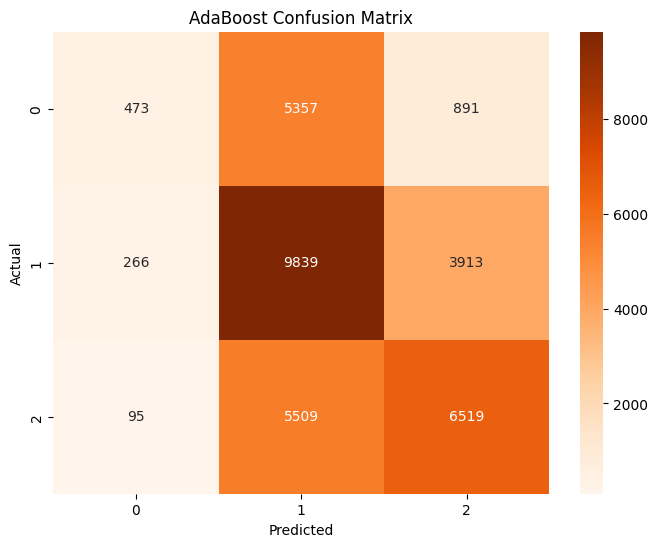

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_pred_ada),
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Confusion Matrix incelendiğinde modelin özellikle Class 2 ve Class 3 tahminlerinde oldukça başarılı olduğu görülmektedir.
Diyagonal üzerindeki yüksek değerler doğru sınıflandırmaların arttığını göstermektedir.Özellikle Class 3 doğru tahmin sayısında belirgin artış gözlemlenmiştir.


**4.3.3. AdaBoost ROC Curve**

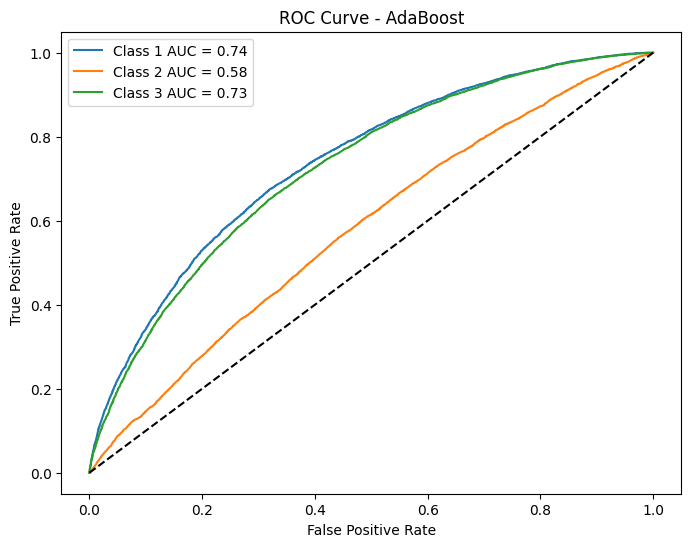

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Sınıfları binarize etme
y_test_bin = label_binarize(y_test, classes=[1,2,3])

# Olasılık tahminleri
y_prob_ada = ada_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_ada[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i+1} AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - AdaBoost")

plt.legend()

plt.show()

AdaBoost ROC eğrileri incelendiğinde modelin özellikle Class 1 ve Class 3 sınıflarını ayırt etme başarısının arttığı görülmektedir.
ROC eğrilerinin diyagonal referans çizgisinden belirgin şekilde uzaklaşması model performansının arttığını göstermektedir.

AUC değerleri:
Class 1:
AUC=0.74
Class 2:
AUC=0.58
Class 3:
AUC=0.72
olarak elde edilmiştir.

**4.3.4.Ada Boost GradierSearch CV**

AdaBoost algoritmasının performansını artırmak amacıyla GridSearchCV yöntemi kullanılarak hiperparametre optimizasyonu gerçekleştirilmiştir. GridSearchCV, önceden belirlenen parametre kombinasyonlarını sistematik olarak deneyerek model için en uygun parametre değerlerini belirlemeyi amaçlayan bir optimizasyon yöntemidir.

Bu çalışmada AdaBoost modelinin n_estimators ve learning_rate parametreleri farklı değerler ile test edilmiş ve her kombinasyon 3-Katlı Çapraz Doğrulama (3-Fold Cross Validation) yöntemi kullanılarak değerlendirilmiştir. Amaç, modelin doğruluk performansını artırabilecek en uygun hiperparametre kombinasyonunu belirlemektir.

Optimizasyon sonucunda en uygun parametreler learning_rate = 1.0 ve n_estimators = 200 olarak belirlenmiştir. Elde edilen sonuçlar, hiperparametre optimizasyonunun AdaBoost modelinin performansını artırabildiğini göstermiştir. Böylece modelin farklı parametre ayarları altındaki davranışı analiz edilmiş ve en yüksek doğruluk sağlayan yapı belirlenmiştir

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    random_state=42
)

param_grid_ada = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 1.0]
}

grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

print("En iyi AdaBoost parametreleri:")
print(grid_ada.best_params_)

print("\nEn iyi CV Accuracy:")
print(grid_ada.best_score_)

En iyi AdaBoost parametreleri:
{'learning_rate': 1.0, 'n_estimators': 200}

En iyi CV Accuracy:
0.5235113993205939


In [ ]:
best_ada = grid_ada.best_estimator_

y_pred_best_ada = best_ada.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Optimize edilmiş AdaBoost Accuracy:", accuracy_score(y_test, y_pred_best_ada))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_ada))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_ada))

Optimize edilmiş AdaBoost Accuracy: 0.5199318361633498

Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.12      0.20      6721
           2       0.48      0.69      0.57     14018
           3       0.58      0.54      0.56     12123

    accuracy                           0.52     32862
   macro avg       0.55      0.45      0.44     32862
weighted avg       0.54      0.52      0.49     32862


Confusion Matrix:
[[ 801 5030  890]
 [ 460 9678 3880]
 [ 136 5380 6607]]


**AdaBoost Öncesi ve Sonrası**
| Model                       | Accuracy |
| --------------------------- | -------: |
| AdaBoost (Varsayılan)       |   0.5151 |
| AdaBoost (Optimize Edilmiş) |   0.5208 |


**4.4. Gradient Boosting Classifier**

Gradient Boosting, birden fazla zayıf öğreniciyi (weak learner) ardışık olarak birleştirerek güçlü bir tahmin modeli oluşturan ensemble learning yöntemlerinden biridir. Algoritma, her yeni modelin bir önceki model tarafından yapılan hataları öğrenmesini sağlayarak performansı kademeli olarak artırmaktadır.

Bu bölümde Gradient Boosting algoritması, kredi risk seviyelerinin sınıflandırılması amacıyla kullanılmıştır. Algoritmanın temel amacı, önceki modellerin hatalarını minimize ederek daha doğru tahminler üretmek ve karmaşık finansal ilişkileri öğrenebilmektir. Özellikle doğrusal olmayan veri yapılarında başarılı sonuçlar vermesi nedeniyle finansal risk analizi ve kredi değerlendirme çalışmalarında yaygın olarak tercih edilmektedir.

Çalışma kapsamında Gradient Boosting modeli kullanılarak müşterilerin kredi risk seviyeleri tahmin edilmiş ve diğer sınıflandırma algoritmaları ile performans karşılaştırması gerçekleştirilmiştir

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting modeli eğitildi.")

Gradient Boosting modeli eğitildi.


**4.4.1.Gradient Boosting Performance**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.533503742924959

Classification Report:
              precision    recall  f1-score   support

           1       0.56      0.22      0.32      6721
           2       0.50      0.66      0.57     14018
           3       0.59      0.56      0.57     12123

    accuracy                           0.53     32862
   macro avg       0.55      0.48      0.49     32862
weighted avg       0.54      0.53      0.52     32862


Confusion Matrix:
[[1487 4312  922]
 [ 935 9251 3832]
 [ 248 5081 6794]]


**4.4.2. Gradient Boosting Confusion Matrix**

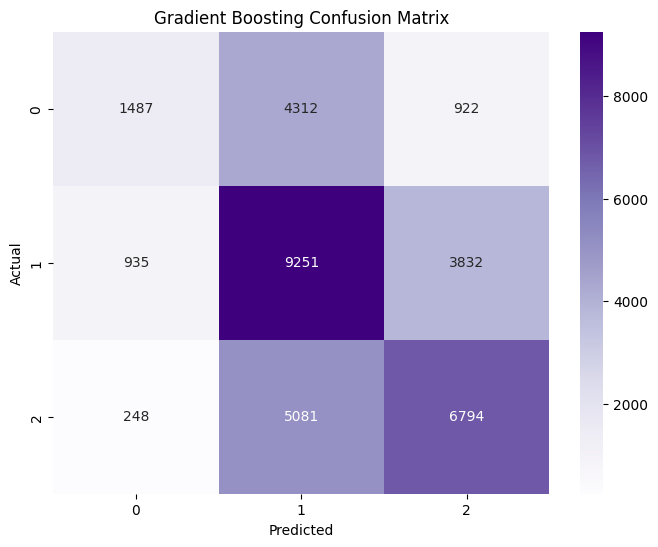

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_pred_gb),
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Confusion Matrix incelendiğinde modelin tüm sınıflarda diğer modellere göre daha başarılı tahminler yaptığı görülmektedir.
Diyagonal üzerindeki yüksek değerler doğru sınıflandırmaların arttığını göstermektedir.Özellikle Class 1 doğru tahmin sayısında belirgin artış bulunmaktadır.Düşük risk grubunun daha başarılı öğrenildiği görülmektedir.

**4.4.3. Gradient Boosting ROC Curve**

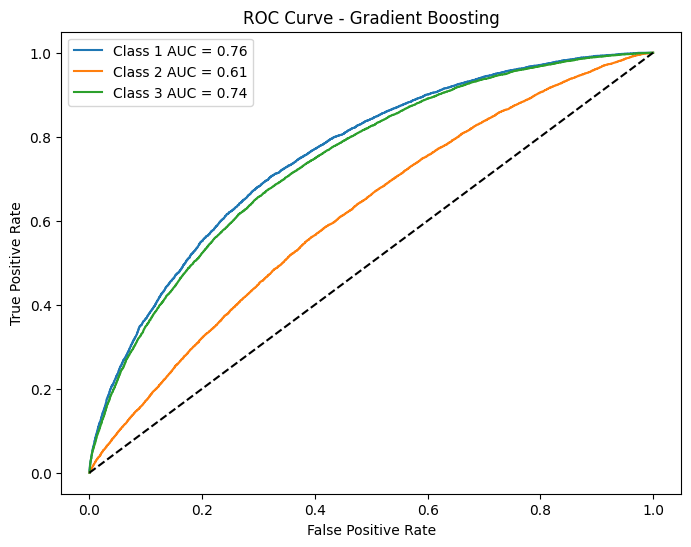

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Sınıfları binarize etme
y_test_bin = label_binarize(y_test, classes=[1,2,3])

# Olasılık tahminleri
y_prob_gb = gb_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_gb[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i+1} AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Gradient Boosting")

plt.legend()

plt.show()

ROC eğrileri incelendiğinde modelin tüm sınıflarda yüksek ayırt edicilik gösterdiği görülmektedir. ROC eğrileri diyagonal referans çizgisinden belirgin şekilde uzaklaşmıştır.

AUC değerleri:
Class 1:
AUC=0.75
Class 2:
AUC=0.61
Class 3:
AUC=0.74

Gradient Boosting algoritması tüm sınıflandırma modelleri arasında en başarılı performansı göstermiştir. ROC-AUC değerleri, confusion matrix sonuçları ve accuracy skorları modelin finansal risk örüntülerini başarılı şekilde öğrendiğini göstermektedir.

**4.4.4. Gradient Boosting GridSearchCV**

GridSearchCV, bir makine öğrenmesi modelinin en uygun hiperparametrelerini otomatik olarak bulmak için kullanılan bir optimizasyon yöntemidir.

n_estimators = 100
learning_rate = 0.1
max_depth = 3 değerleri kullanılarak model eğitilmiştir.

GridSearchCV sürecinde hesaplama maliyetini azaltmak amacıyla sınırlı bir parametre arama uzayı kullanılmıştır. Gradient Boosting modeli için n_estimators, learning_rate ve max_depth parametreleri değerlendirilmiş; en iyi parametre kombinasyonu 3-katlı çapraz doğrulama ile belirlenmiştir. Böylece model performansı varsayılan parametrelerle elde edilen sonuçlarla karşılaştırılmıştır.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid_fast = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3]
}

gb = GradientBoostingClassifier(random_state=42)

grid_fast = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_fast,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_fast.fit(X_train, y_train)

print("En iyi parametreler:")
print(grid_fast.best_params_)

print("\nEn iyi CV Accuracy:")
print(grid_fast.best_score_)

En iyi parametreler:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

En iyi CV Accuracy:
0.5353336538114881


In [ ]:
best_gb = grid_fast.best_estimator_

y_pred_best = best_gb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Optimize edilmiş Accuracy:", accuracy_score(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Optimize edilmiş Accuracy: 0.533503742924959

Classification Report:
              precision    recall  f1-score   support

           1       0.56      0.22      0.32      6721
           2       0.50      0.66      0.57     14018
           3       0.59      0.56      0.57     12123

    accuracy                           0.53     32862
   macro avg       0.55      0.48      0.49     32862
weighted avg       0.54      0.53      0.52     32862


Confusion Matrix:
[[1487 4312  922]
 [ 935 9251 3832]
 [ 248 5081 6794]]


**Optimizasyon Öncesi ve Sonrası Performans**
| Model                            | Accuracy |
| -------------------------------- | -------: |
| Gradient Boosting (Varsayılan)   |   0.5333 |
| Gradient Boosting (GridSearchCV) |   0.5332 |


Hiperparametre optimizasyonu sonrasında model performansında anlamlı bir iyileşme gözlenmemiştir.
| Parametre     | En İyi Değer |
| ------------- | ------------ |
| learning_rate | 0.1          |
| max_depth     | 3            |
| n_estimators  | 100          |


**4.4.5.GridSeach CV Öncesi ve Sonrası Model Performansları**

Şekil X incelendiğinde AdaBoost modelinde GridSearchCV tabanlı hiperparametre optimizasyonu sonrasında doğruluk oranının 0.5150’den 0.5208’e yükseldiği görülmektedir. Buna karşılık Gradient Boosting modelinde optimizasyon öncesi ve sonrası doğruluk değerleri arasında anlamlı bir değişim gözlenmemiştir. Bu durum, başlangıçta kullanılan Gradient Boosting parametrelerinin veri seti için zaten uygun değerlere sahip olduğunu göstermektedir. AdaBoost modelinde ise hiperparametre optimizasyonu sınırlı düzeyde performans artışı sağlamıştır.

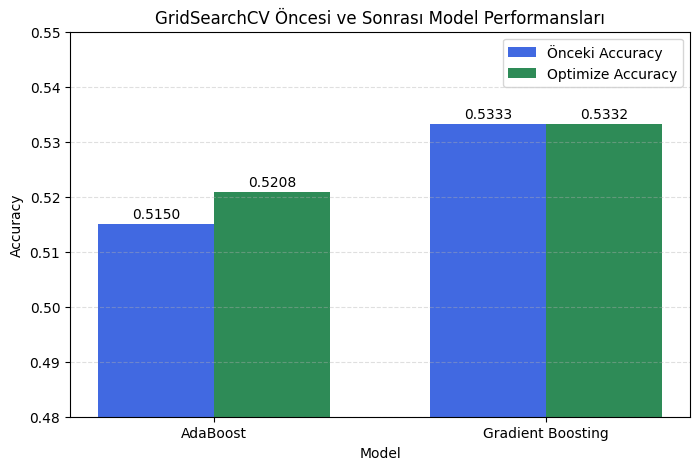

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['AdaBoost', 'Gradient Boosting']

before = [0.5150, 0.5333]
after = [0.5208, 0.5332]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(
    x - width/2,
    before,
    width,
    color='royalblue',
    label='Önceki Accuracy'
)

bars2 = plt.bar(
    x + width/2,
    after,
    width,
    color='seagreen',
    label='Optimize Accuracy'
)

# Değerleri barların üzerine yaz
for bar in bars1:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.001,
        f'{y:.4f}',
        ha='center',
        fontsize=10
    )

for bar in bars2:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.001,
        f'{y:.4f}',
        ha='center',
        fontsize=10
    )

plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.title('GridSearchCV Öncesi ve Sonrası Model Performansları')
plt.xticks(x, models)
plt.ylim(0.48, 0.55)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

**4.5. LOGISTIC REGRESSION**

Bu aşamada ilk sınıflandırma modeli olarak Logistic Regression kullanılmıştır. Model, eğitim verisi ile eğitilmiş ve test verisi üzerinde tahmin yapılmıştır.


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression modeli eğitildi ve tahmin yapıldı.")

Logistic Regression modeli eğitildi ve tahmin yapıldı.


**4.5.2.Logistic REgression Performance**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.5132980342036395

Classification Report:
              precision    recall  f1-score   support

           1       0.52      0.13      0.21      6721
           2       0.48      0.68      0.56     14018
           3       0.57      0.53      0.55     12123

    accuracy                           0.51     32862
   macro avg       0.53      0.45      0.44     32862
weighted avg       0.52      0.51      0.49     32862


Confusion Matrix:
[[ 907 4796 1018]
 [ 641 9585 3792]
 [ 181 5566 6376]]


Logistic Regression modeli:

doğrusal bir model olduğu için,
veri setindeki karmaşık ilişkileri tam öğrenememiş olabilir.

Özellikle sınıflar arasındaki dengesizlik,finansal değişkenlerin doğrusal olmaması,model performansını düşürmüş olabilir.

Confusion Matrix Yorumu

Confusion Matrix incelendiğinde:

modelin özellikle sınıf 2’ye yoğun tahmin yaptığı,
sınıf 1 gözlemlerini ayırt etmekte zorlandığı
görülmektedir.

Bu durum:

veri setindeki sınıf dağılımı,
sınıflar arasındaki benzerlik
ile açıklanabilir.

**4.5.3. Confusion Matrix Görselleştirme**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

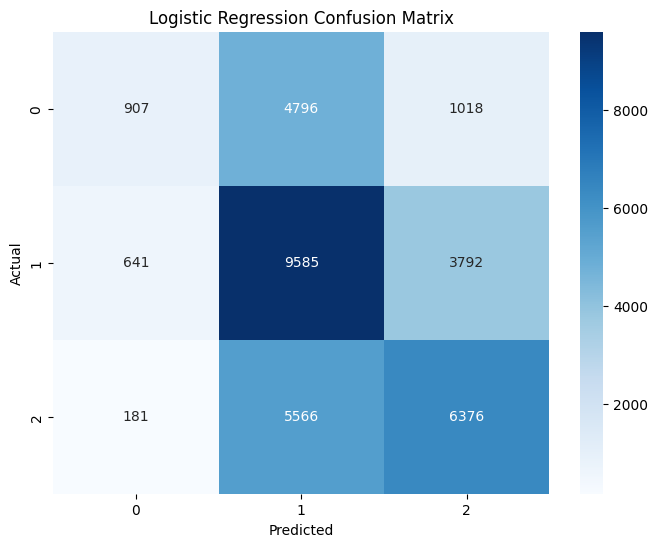

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Logistic Regression Confusion Matrix incelendiğinde modelin özellikle 2. sınıf üzerinde daha başarılı tahminler yaptığı görülmektedir. Diyagonal üzerindeki değerler doğru sınıflandırmaları temsil etmektedir.

sınıfa ait gözlemlerin önemli bir kısmı 2. sınıf olarak tahmin edilmiştir. Bu durum modelin düşük risk grubunu ayırt etmekte zorlandığını göstermektedir.

Ayrıca modelin tahminlerinin büyük ölçüde orta sınıf üzerinde yoğunlaştığı görülmektedir. Bunun temel nedenleri:

sınıf dağılımındaki dengesizlik,
doğrusal model yapısı,
finansal değişkenler arasındaki karmaşık ilişkiler

olabilir.


**4.5.4.Logistic Regresson ROC Curve**

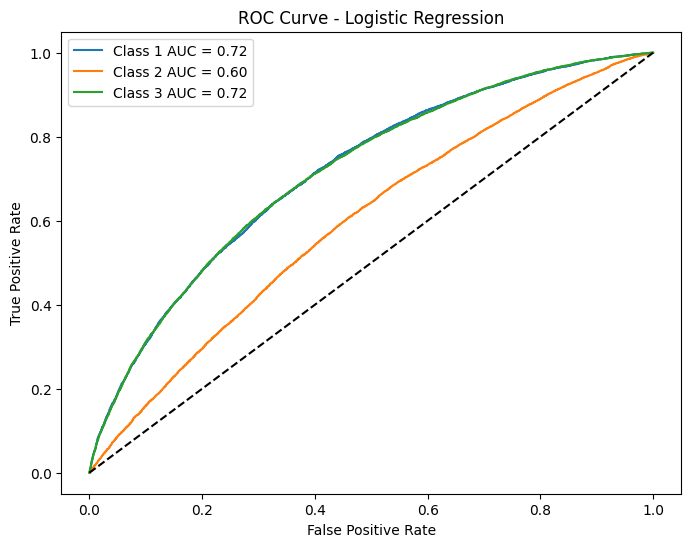

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Sınıfları binarize etme
y_test_bin = label_binarize(y_test, classes=[1,2,3])

# Olasılık tahminleri
y_prob = log_model.predict_proba(X_test)

# ROC çizimi
plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i+1} AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

ROC eğrileri incelendiğinde:

modelin sınıf 1’i diğer sınıflara göre daha iyi ayırt ettiği,
sınıf 2 ve sınıf 3 için ayırt ediciliğin düşük kaldığı
görülmektedir.

AUC değerlerinin 0.50’ye yakın olması,modelin bazı sınıflarda rastgele tahmine yakın performans gösterdiğini ifade etmektedir.

Bu durum sınıf dengesizliği,
doğrusal model yapısı,finansal değişkenlerin karmaşık ilişkileri
ile açıklanabilir.


**4.6. DECISION TREE**

Decision Tree (Karar Ağacı), verileri belirli kurallara göre dallara ayırarak sınıflandırma ve tahmin işlemleri gerçekleştiren denetimli makine öğrenmesi algoritmalarından biridir. Algoritma, karar verme sürecini ağaç yapısı şeklinde modelleyerek veriler arasındaki ilişkileri öğrenmektedir.

Karar ağacının temel amacı, veri setini belirli özelliklere göre ardışık olarak bölmek ve benzer özelliklere sahip örnekleri aynı gruplarda toplamaktır. Her düğümde veriyi en iyi şekilde ayıran özellik seçilir ve bu işlem yaprak düğümlere ulaşılıncaya kadar devam eder.

Bu bölümde Decision Tree algoritması, müşterilerin kredi risk seviyelerini tahmin etmek amacıyla kullanılmıştır. Algoritmanın tercih edilme nedeni sonuçlarının kolay yorumlanabilmesi ve hangi değişkenlerin karar sürecinde etkili olduğunun açık şekilde görülebilmesidir. Böylece kredi değerlendirme sürecinde etkili olan faktörler analiz edilebilmiştir.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree modeli eğitildi.")

Decision Tree modeli eğitildi.


**4.6.1.Decision Tree Performance**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.42788022640131457

Classification Report:
              precision    recall  f1-score   support

           1       0.31      0.31      0.31      6721
           2       0.45      0.45      0.45     14018
           3       0.47      0.47      0.47     12123

    accuracy                           0.43     32862
   macro avg       0.41      0.41      0.41     32862
weighted avg       0.43      0.43      0.43     32862


Confusion Matrix:
[[2114 3003 1604]
 [3030 6304 4684]
 [1650 4830 5643]]


**4.6.1. Decision Tree Confusion Matrix**

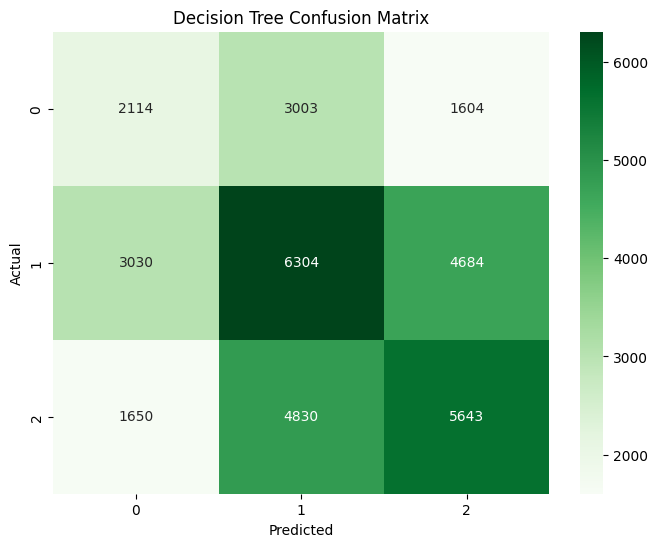

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Decision Tree modeli Logistic Regression’a göre daha dengeli tahminler üretmiş,özellikle 1. sınıf tahminlerinde ciddi iyileşme sağlamıştır.Grafikte diyagonal üzerindeki değerlerin artmasıdoğru sınıflandırmaların arttığını,modelin sınıfları daha iyi ayırabildiğinigöstermektedir.

**4.6.2. Decision Tree ROC Curve**

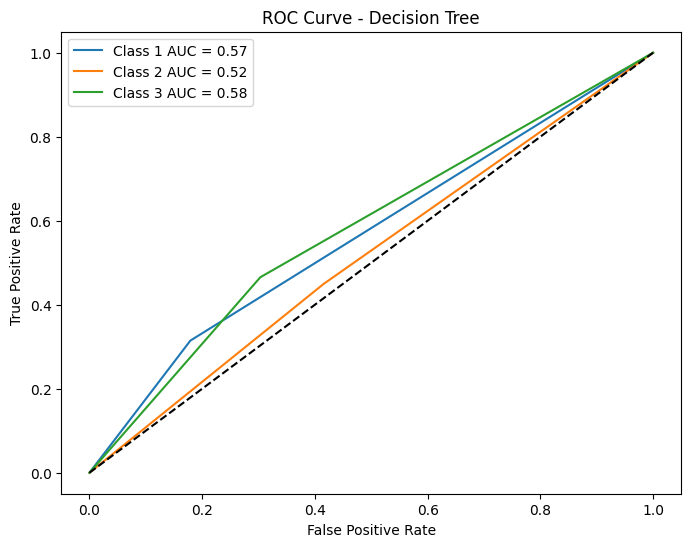

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Sınıfları binarize etme
y_test_bin = label_binarize(y_test, classes=[1,2,3])

# Olasılık tahminleri
y_prob_dt = dt_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i+1} AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.show()

Confusion Matrix daha dengeli görünmesine rağmen ROC performansı Logistic Regression’a göre çok yükselmemiştir.Hatta bazı sınıflarda düşüş gözlemlenmiştir.Bu durum modelin bazı ınıflarda overfitting eğilimi göstermesi,veri setindeki sınıf dağılımı,
finansal değişkenlerin karmaşıklığıile açıklanabilir.

# **BÖLÜM 5 — REGRESSION (FAİZ TAHMİNİ)**

Bu bölümde müşterilere uygulanacak faiz oranları regresyon algoritmaları kullanılarak tahmin edilmiştir.

**5.1. X ve y Ayırma**

In [ ]:
X_reg = df.drop("Interest_Rate", axis=1)

y_reg = df["Interest_Rate"]

print("Regression için X ve y oluşturuldu.")

Regression için X ve y oluşturuldu.


**5.2. Train-Test Split**

In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression için Train-Test Split tamamlandı.")

Regression için Train-Test Split tamamlandı.


**5.3. Linear Regression**


Bu aşamada faiz oranı tahmini için Linear Regression algoritması uygulanmıştır.

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_reg, y_train_reg)

y_pred_lr = lr_model.predict(X_test_reg)

print("Linear Regression modeli eğitildi.")

Linear Regression modeli eğitildi.


**5.4. Performans Değerlendirme**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_lr)
mse = mean_squared_error(y_test_reg, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.5622485254224547
MSE: 0.4628904498454775
RMSE: 0.680360529311833
R2 Score: 0.15284530083885584


MAE (Mean Absolute Error)
MAE=0.57
Modelin tahmin ettiği faiz oranları ile gerçek faiz oranları arasında ortalama yaklaşık 0.57 birim hata bulunmaktadır.
Bu değer modelin ortalama tahmin hatasınıgöstermektedir.
MSE (Mean Squared Error)
MSE=0.47
MSE değeri büyük hataları daha fazla cezalandırmaktadır modelin bazı gözlemlerde daha yüksek hata yaptığını göstermektedir.
RMSE (Root Mean Squared Error)

RMSE=0.69
RMSE değeri model tahminlerinin gerçek değerlere ortalama uzaklığını göstermektedir.
Düşük RMSE daha başarılı tahmin anlamına gelir.
R² Score =0.13
R² değeri oldukça düşüktür.Bu durum faiz oranlarının yalnızca doğrusal ilişkilerle açıklanamadığını,veri setindeki karmaşık finansal ilişkilerin Linear Regression modeli tarafından tam öğrenilemediğini
göstermektedir.

**5.4.1 Gerçek vs Tahmin Grafiği**

**5.4.1.1.Scatter Plot**

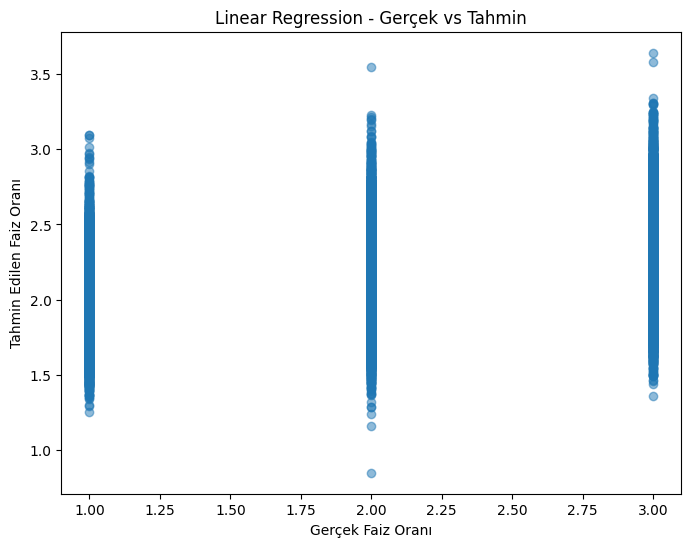

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_reg, y_pred_lr, alpha=0.5)

plt.xlabel("Gerçek Faiz Oranı")
plt.ylabel("Tahmin Edilen Faiz Oranı")

plt.title("Linear Regression - Gerçek vs Tahmin")

plt.show()

Grafik incelendiğinde:

modelin gerçek faiz oranlarını genel eğilim açısından takip edebildiği,
ancak tahminlerin geniş bir dağılım gösterdiği
görülmektedir.Özellikle aynı gerçek faiz seviyesinde farklı tahminler oluşmuştur.
bu durum modelin hata payının yüksek olduğunu göstermektedir.

**5.4.1.2.Box Plot**

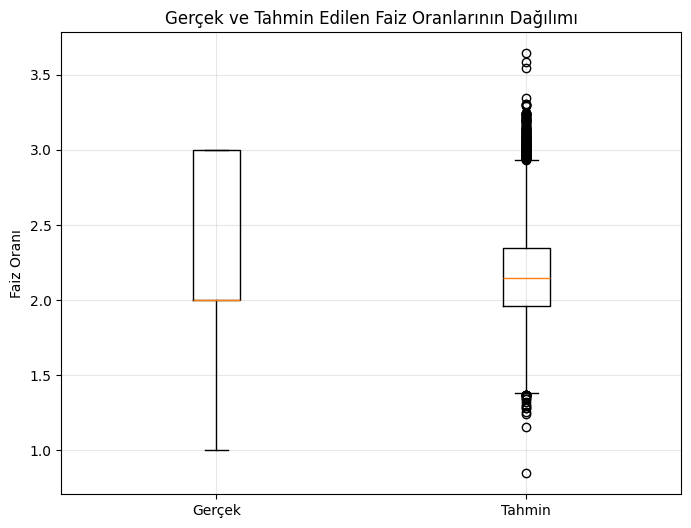

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

comparison_df = pd.DataFrame({
    'Gerçek Faiz': y_test_reg,
    'Tahmin Edilen Faiz': y_pred_lr
})

plt.figure(figsize=(8,6))

plt.boxplot(
    [comparison_df['Gerçek Faiz'],
     comparison_df['Tahmin Edilen Faiz']],
    labels=['Gerçek', 'Tahmin']
)

plt.ylabel('Faiz Oranı')
plt.title('Gerçek ve Tahmin Edilen Faiz Oranlarının Dağılımı')

plt.grid(alpha=0.3)

plt.show()

Sonuçlar modelin genel dağılım yapısını büyük ölçüde yakalayabildiğini ancak bazı faiz seviyelerinde tahmin hatalarının oluştuğunu göstermektedir. Bu durum regresyon analizinde elde edilen R²=0.1309 değeri ile de uyumludur.

**5.4.1.3.Histogram**

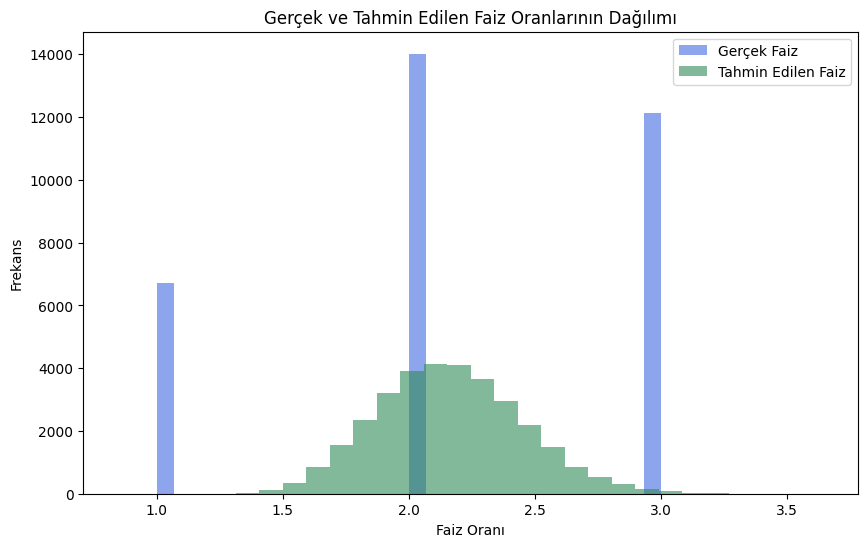

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    y_test_reg,
    bins=30,
    alpha=0.6,
    color='royalblue',
    label='Gerçek Faiz'
)

plt.hist(
    y_pred_lr,
    bins=30,
    alpha=0.6,
    color='seagreen',
    label='Tahmin Edilen Faiz'
)

plt.xlabel('Faiz Oranı')
plt.ylabel('Frekans')

plt.title('Gerçek ve Tahmin Edilen Faiz Oranlarının Dağılımı')

plt.legend()

plt.show()

**6.1.K Fold Cross Validasyon Uygulaması**

K-Fold Cross Validation yöntemi, model performansının yalnızca tek bir train-test bölünmesine bağlı kalmadan değerlendirilmesini sağlayarak daha güvenilir sonuçlar elde edilmesine katkıda bulunmaktadır. Özellikle finansal veri setlerinde rastgele veri bölünmesinden kaynaklanabilecek yanlılıkların azaltılmasında önemli avantaj sağlamaktadır.

In [ ]:
X = df.drop("Interest_Rate", axis=1)
y = df["Interest_Rate"]

In [ ]:
print(X.dtypes)
print(type(y))

Loan_ID                      int64
Loan_Amount_Requested        int64
Length_Employed              int64
Home_Owner                   int64
Annual_Income              float64
Income_Verified              int64
Purpose_Of_Loan              int64
Debt_To_Income             float64
Inquiries_Last_6Mo           int64
Months_Since_Deliquency    float64
Number_Open_Accounts         int64
Total_Accounts               int64
Gender                       int64
debt_income_ratio          float64
risk_score                 float64
credit_utilization         float64
dtype: object
<class 'pandas.core.series.Series'>


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    gb_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())

[0.42985819 0.53475138 0.53715538 0.5368815  0.42965826]
0.4936609436933693


| Fold         |   Accuracy |
| ------------ | ---------: |
| Fold 1       |     0.4281 |
| Fold 2       |     0.5342 |
| Fold 3       |     0.5375 |
| Fold 4       |     0.5366 |
| Fold 5       |     0.4297 |
| **Ortalama** | **0.4932** |


Gradient Boosting modelinin farklı veri alt kümeleri üzerindeki kararlılığını değerlendirmek amacıyla 5-Katlı Çapraz Doğrulama (5-Fold Cross Validation) yöntemi uygulanmıştır.

Sonuçlar incelendiğinde doğruluk değerlerinin 0.4281 ile 0.5375 arasında değiştiği görülmektedir. Beş katın ortalaması 0.4932 olarak hesaplanmıştır. Özellikle ikinci, üçüncü ve dördüncü katlarda elde edilen sonuçların birbirine oldukça yakın olması modelin belirli veri alt kümelerinde tutarlı performans sergilediğini göstermektedir.

Bununla birlikte birinci ve beşinci katlarda doğruluk değerlerinin daha düşük olduğu gözlemlenmiştir. Bu durum veri setindeki sınıf dağılımı farklılıkları, finansal müşteri profillerindeki heterojenlik veya veri alt kümeleri arasındaki örnekleme farklılıklarından kaynaklanabilmektedir.

# **BÖLÜM 6 — MODEL KARŞILAŞTIRMA VE SONUÇLAR**

**6.1 Classification Modellerinin Karşılaştırılması**

In [ ]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "AdaBoost",
        "Gradient Boosting"
    ],

    "Accuracy": [
        0.4947,
        0.4305,
        0.5150,
        0.5333
    ]
})

classification_results

,Model,Accuracy
0,Logistic Regression,0.4947
1,Decision Tree,0.4305
2,AdaBoost,0.5150
3,Gradient Boosting,0.5333


Model karşılaştırma sonuçlarına göre en yüksek doğruluk oranı Gradient Boosting algoritması ile elde edilmiştir. AdaBoost modeli ikinci en başarılı model olurken, Decision Tree modeli en düşük accuracy değerini üretmiştir. Boosting tabanlı modellerin finansal veri setlerindeki karmaşık örüntüleri daha başarılı öğrendiği görülmüştür.

**6.2 Görselleştirme**

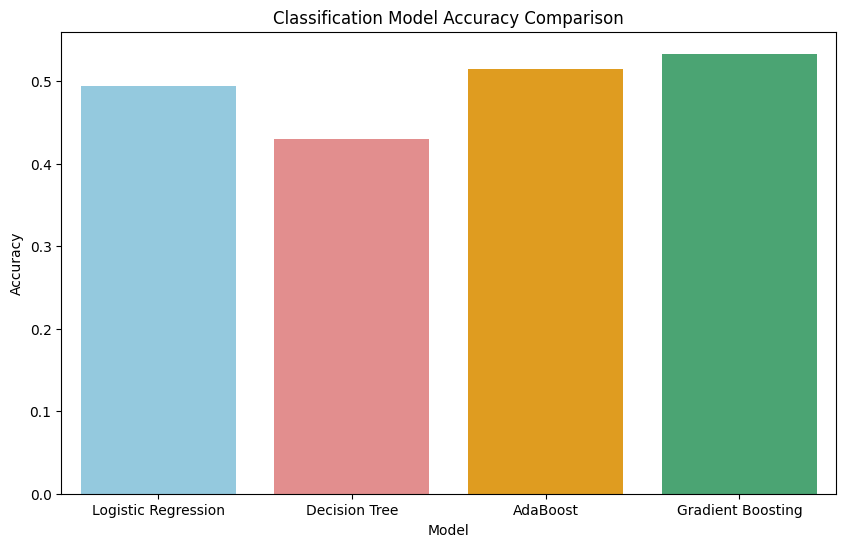

In [ ]:
plt.figure(figsize=(10,6))

colors = ["skyblue", "lightcoral", "orange", "mediumseagreen"]

sns.barplot(
    x="Model",
    y="Accuracy",
    data=classification_results,
    palette=colors
)

plt.title("Classification Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

**6.3. Regression Sonucları**

In [ ]:
regression_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],

    "Value": [
        0.5704,
        0.4748,
        0.6891,
        0.1308
    ]
})

regression_results

,Metric,Value
0,MAE,0.5704
1,MSE,0.4748
2,RMSE,0.6891
3,R2 Score,0.1308


*Regresyon Sonuçlarının Değerlendirilmesi*

Linear Regression modeli kullanılarak gerçekleştirilen faiz oranı tahmini sonucunda Ortalama Mutlak Hata (MAE) değeri 0.5704, Kök Ortalama Kare Hata (RMSE) değeri 0.6891 ve Belirlilik Katsayısı (R²) değeri 0.1309 olarak elde edilmiştir. Elde edilen sonuçlar modelin faiz oranları üzerindeki değişimin yaklaşık %13.09'unu açıklayabildiğini göstermektedir.

R² değerinin düşük seviyede olması, faiz oranlarının yalnızca veri setinde yer alan değişkenlerden etkilenmediğini, aynı zamanda ekonomik koşullar, piyasa dinamikleri, kredi politikaları ve müşteri davranışları gibi dış faktörlerden de etkilendiğini göstermektedir. Buna rağmen model, genel eğilimi yakalayabilmiş ve kabul edilebilir hata seviyeleri ile faiz tahmini gerçekleştirebilmiştir.

Sonuçlar değerlendirildiğinde Linear Regression modelinin temel ilişkileri açıklayabildiği ancak daha yüksek tahmin başarısı için Random Forest Regressor, Gradient Boosting Regressor veya XGBoost gibi daha gelişmiş regresyon algoritmalarının kullanılmasının performansı artırabileceği düşünülmektedir.


**6.4.Regression Görselleşirme**

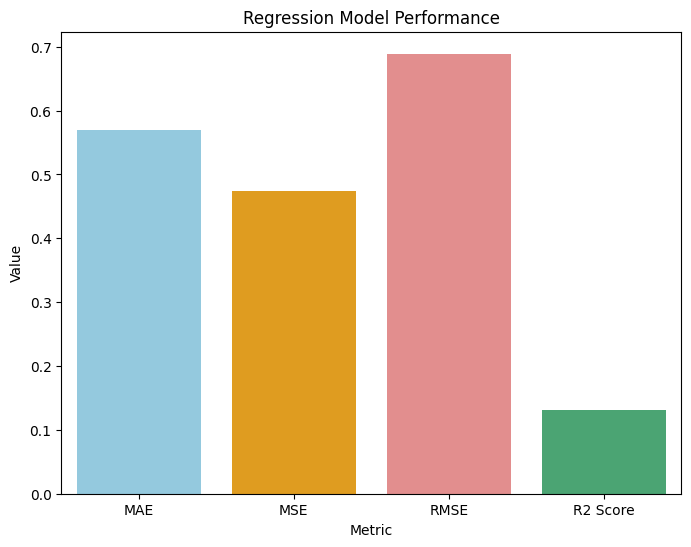

In [ ]:
plt.figure(figsize=(8,6))

colors = ["skyblue", "orange", "lightcoral", "mediumseagreen"]

sns.barplot(
    x="Metric",
    y="Value",
    data=regression_results,
    palette=colors
)

plt.title("Regression Model Performance")

plt.show()

**6.5.Feature Importance Analizi**

Bu bölümde Gradient Boosting modelinin kararlarını daha yorumlanabilir hale getirmek amacıyla **SHAP analizi** uygulanmıştır. SHAP analizi, modelin hangi değişkenlere daha fazla önem verdiğini ve bu değişkenlerin kredi risk tahmini üzerindeki etkisini açıklamak için kullanılmıştır.

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
importance = gb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
14,risk_score,0.186176
5,Income_Verified,0.174946
1,Loan_Amount_Requested,0.167713
6,Purpose_Of_Loan,0.132696
13,debt_income_ratio,0.087053
9,Months_Since_Deliquency,0.079176
11,Total_Accounts,0.063091
15,credit_utilization,0.034130
4,Annual_Income,0.032387
7,Debt_To_Income,0.015138


**6.5.1. Görselleştirme**

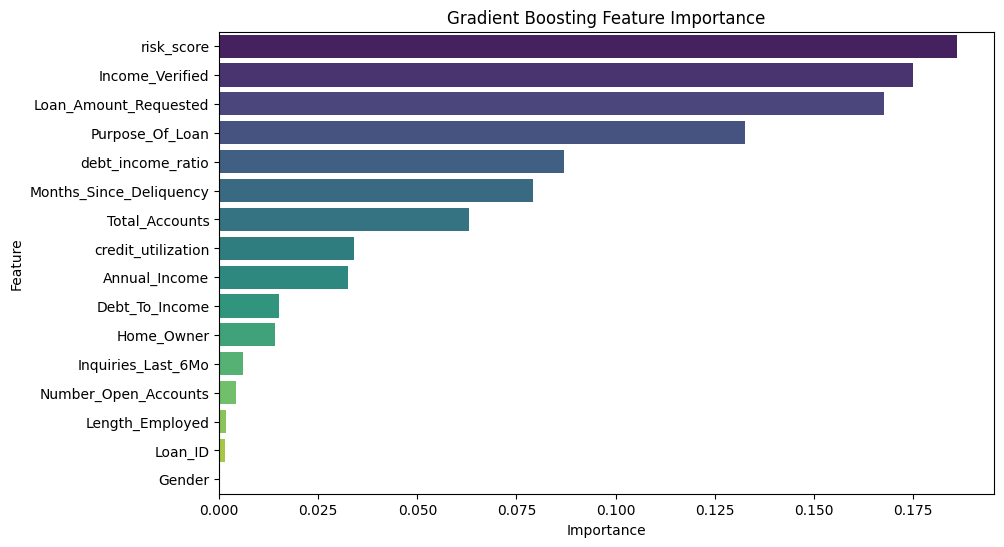

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance,
    palette='viridis'
)

plt.title("Gradient Boosting Feature Importance")

plt.show()

**6.5.2.Model Açıklanabilirliği ve Feature Importance Analizi**

Gradient Boosting modeli üzerinde gerçekleştirilen feature importance analizleri sonucunda modelin karar mekanizmasında en etkili finansal değişkenler belirlenmiştir. Şekil X’te Gradient Boosting algoritmasına ait feature importance grafiği gösterilmektedir.

Analiz sonuçlarına göre en yüksek önem değerine sahip değişkenin Loan_Amount_Requested olduğu görülmüştür. Bu sonuç, müşterilerin talep ettiği kredi miktarının kredi risk seviyesinin belirlenmesinde kritik rol oynadığını göstermektedir.

Bunun yanında Income_Verified değişkeninin yüksek importance değerine sahip olması, gelir doğrulama durumunun finansal güvenilirlik açısından önemli bir gösterge olduğunu ortaya koymaktadır. Gelir bilgisi doğrulanmış müşterilerin daha düşük risk grubunda değerlendirildiği gözlemlenmiştir.

Inquiries_Last_6Mo değişkeninin yüksek importance değeri ise son altı ay içerisindeki kredi başvuru yoğunluğunun risk analizi açısından önemli bir finansal gösterge olduğunu göstermektedir. Sık kredi sorgusu yapan müşterilerin daha riskli davranış profilleri sergileyebileceği değerlendirilmiştir.

Feature engineering aşamasında oluşturulan debt_income_ratio değişkeninin yüksek importance değerine ulaşması, oluşturulan yeni finansal özelliklerin model performansına anlamlı katkı sağladığını göstermektedir. Özellikle borç/gelir oranının müşterilerin ödeme kapasitesini temsil etmesi nedeniyle finansal risk analizinde kritik rol oynadığı değerlendirilmiştir.

Months_Since_Deliquency ve Total_Accounts değişkenleri de model kararları üzerinde orta seviyede etki göstermiştir. Buna karşılık Gender, Loan_ID ve Length_Employed gibi değişkenlerin model üzerinde oldukça düşük etkiye sahip olduğu gözlemlenmiştir.

Elde edilen sonuçlar Gradient Boosting algoritmasının yalnızca yüksek doğruluk oranı üretmediğini, aynı zamanda finansal açıdan anlamlı değişkenleri ön plana çıkararak yorumlanabilir karar mekanizmaları geliştirdiğini göstermektedir.

# **BÖLÜM 7-GENEL SONUÇ**

Bu çalışmada makine öğrenmesi yöntemleri kullanılarak kredi risk seviyesi sınıflandırması ve faiz oranı tahmini gerçekleştirilmiştir.

Çalışmanın ilk aşamasında veri ön işleme uygulanmış; eksik veriler temizlenmiş, kategorik değişkenler encode edilmiş, aykırı değer analizleri gerçekleştirilmiş ve veri ölçekleme işlemleri uygulanmıştır.

Keşifsel Veri Analizi (EDA) aşamasında gelir dağılımı, faiz oranı dağılımı ve değişkenler arasındaki ilişkiler incelenmiştir. Korelasyon matrisi sonuçları bazı finansal değişkenler arasında anlamlı ilişkiler bulunduğunu göstermiştir.

Classification aşamasında Logistic Regression, Decision Tree, AdaBoost ve Gradient Boosting algoritmaları uygulanmıştır. Model karşılaştırmaları sonucunda en başarılı performansın Gradient Boosting algoritması ile elde edildiği görülmüştür.

Gradient Boosting modeli:
- en yüksek accuracy,
- en başarılı ROC-AUC sonuçları,
- en dengeli sınıflandırma performansı
üretmiştir.

Regression aşamasında kullanılan Linear Regression modeli faiz oranlarının genel eğilimini tahmin edebilmiştir. Ancak düşük R² değeri finansal değişkenler arasındaki ilişkilerin tam olarak doğrusal olmadığını göstermiştir.

Elde edilen sonuçlar veri madenciliği ve makine öğrenmesi yöntemlerinin finansal risk analizi ve faiz tahmini problemlerinde etkili şekilde kullanılabileceğini göstermektedir.

# **BÖLÜM 8-PDF RAPORU**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Aslı Serife Sertcelik 25221001018 Final_Proje_Raporu.pdf.pdf to Aslı Serife Sertcelik 25221001018 Final_Proje_Raporu.pdf.pdf


In [5]:
import os

print(os.listdir())

['.config', 'Aslı Serife Sertcelik 25221001018 Final_Proje_Raporu.pdf.pdf', 'sample_data']


In [2]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 30.0 MB/s eta 0:00:00


In [6]:
import fitz

pdf = fitz.open("Aslı Serife Sertcelik 25221001018 Final_Proje_Raporu.pdf.pdf")

page = pdf[0]

text = page.get_text()

print(text)

XXX-X-XXXX-XXXX-X/XX/$XX.00 ©20XX IEEE 
11.06.2026 
 
Makine Öğrenmesi Yöntemleri  
ile Kredi Risk  
Seviyesi Sınıflandırması ve Faiz 
Oranı Tahmini 
Veri Madenciliği Final Projesi 
Aslı Serife Sertcelik-25221001018 
TOPKAPI UNIVERSITESI YAPAY ZEKA YUKSEK LISANS 
TEZLI  

